In [6]:
import sys
sys.path.append('../')

import re
import numpy as np
import pandas as pd
import pyvinecopulib as pv
import seaborn as sns
import matplotlib.pyplot as plt

import json

### Read AIA results

In [7]:
# Read AIA results
with open('../tests_simulated_data/inference/runconfig.json') as file:
        runconfig = json.load(file)

# Read regression coefficients from AIA game
regCoeff = pd.read_csv("../tests_simulated_data/inference/reg_coeff_dict_keys(['x1', 'x6', 'x12']).csv")

# Parameters
d = regCoeff.shape[1] - 3
nIter = runconfig['nIter']
nSynT = runconfig['nSynT']

IMRV(0.25, 20)
IMRV(0.5, 20)
IMRV(0.75, 20)
CvineSensitive(5, 20)
Cvine(1)
Cvine(5)
Cvine(10)
Cvine(15)
Cvine(20)
PrivBayes(0.1)
PrivBayes(1.0)
PrivBayes(5.0)
CTGAN(1000, 500)
TVAE(1500, 400)
PrivPGD(2.5, 1e-05)


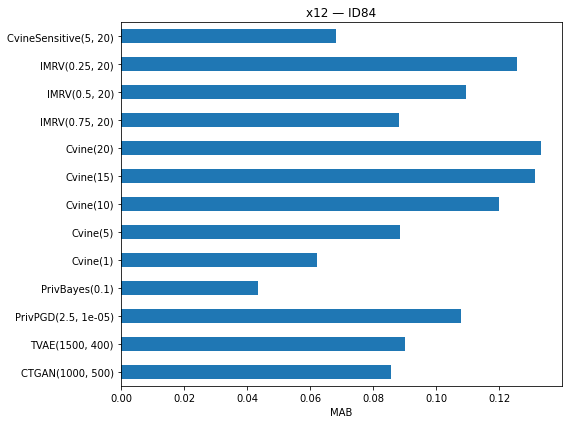

In [8]:
sa = "x12"
tid = "ID84"
MAB = []
for gm in regCoeff.genModel.unique():
    print(gm)
    df = regCoeff.loc[(regCoeff["sa"]==sa) & (regCoeff["tid"] == tid) & (regCoeff["genModel"]==gm),]
    mab = df[df.columns[range(d)]].abs().sum().sum()/(d*df.shape[0])
    MAB.append(mab)

coefficients = [f"b{i}" for i in range(d)]
MAB = regCoeff.groupby(['sa', 'tid', 'genModel'])[coefficients].apply(lambda x: x.abs().to_numpy().sum()/(d*nIter*nSynT))
MAB.name = "MAB"

sub = MAB.loc[(sa,tid)]
order = [
    'CTGAN(1000, 500)',
    'TVAE(1500, 400)', 
    'PrivPGD(2.5, 1e-05)',
    'PrivBayes(0.1)',
    'Cvine(1)',
    'Cvine(5)',
    'Cvine(10)',
    'Cvine(15)', 
    'Cvine(20)', 
    'IMRV(0.75, 20)',
    'IMRV(0.5, 20)',
    'IMRV(0.25, 20)',
    'CvineSensitive(5, 20)',
]
sub = sub.reindex(order)
ax = sub.plot.barh(figsize=(8, 6))
ax.set_xlabel("MAB")
ax.set_ylabel("")
ax.set_title(f"{sa} — {tid}")
plt.tight_layout()
plt.show()

### Read utility results

In [11]:
with open('../tests_simulated_data/utility/utility_metrics_real_data.json') as file:
        utility_metrics = json.load(file)
# utility_metrics = pd.DataFrame(utility_metrics)

In [36]:
auc = {}
for gm in utility_metrics.keys():
    auc[gm] = utility_metrics[gm]['AUC-ROC']
auc = pd.DataFrame(auc)

In [39]:
utility = auc.mean()
utility.name = "AUC-ROC"
utility

Raw                      0.999459
IMRV(0.25, 20)           0.886855
IMRV(0.5, 20)            0.893059
IMRV(0.75, 20)           0.884868
CvineSensitive(5, 20)    0.946330
Cvine(1)                 0.902878
Cvine(5)                 0.936057
Cvine(10)                0.945841
Cvine(15)                0.940509
Cvine(20)                0.934987
PrivBayes(0.1)           0.506963
PrivBayes(1.0)           0.535019
PrivBayes(5.0)           0.539834
CTGAN(1000, 500)         0.781252
TVAE(1500, 400)          0.980046
PrivPGD(2.5, 1e-05)      0.523757
Name: AUC-ROC, dtype: float64

### Make privacy utility plots

In [40]:
privacy_utility_df = pd.concat([utility, MAB.loc[(sa, tid)]], axis=1)

In [41]:
df = privacy_utility_df

In [42]:
df

,AUC-ROC,MAB
Raw,0.999459,NaN
"IMRV(0.25, 20)",0.886855,0.125559
"IMRV(0.5, 20)",0.893059,0.109624
"IMRV(0.75, 20)",0.884868,0.088204
"CvineSensitive(5, 20)",0.946330,0.068338
Cvine(1),0.902878,0.062300
Cvine(5),0.936057,0.088602
Cvine(10),0.945841,0.120073
Cvine(15),0.940509,0.131451
Cvine(20),0.934987,0.133205


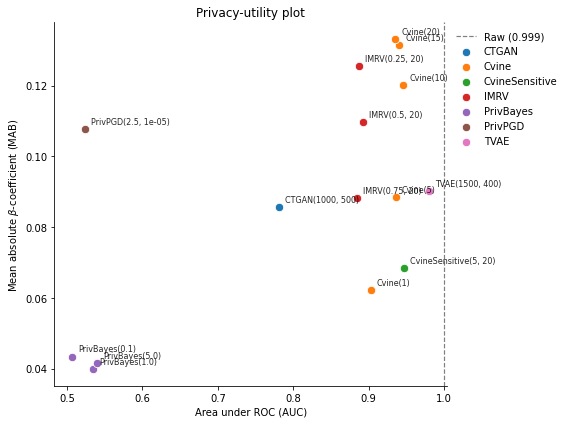

In [43]:
# df: index = model names, columns = ['AUC-ROC', 'MAB']

def short_name(s):
    m = re.match(r'([^(]+)\((.*)\)', s)
    if not m:
        return s, s
    family, args = m.group(1), m.group(2)
    nums = re.findall(r'=\s*([\d.]+)', args)          # "trunc_lvl=15" -> "15"
    return family, f"{family} ({', '.join(nums)})" if nums else family

raw_auc = df.loc['Raw', 'AUC-ROC']
plot_df = df.drop(index='Raw').copy()

families, labels = zip(*[short_name(i) for i in plot_df.index])
plot_df['family'], plot_df['label'] = families, labels

fig, ax = plt.subplots(figsize=(8, 6))

palette = dict(zip(sorted(set(families)), plt.cm.tab10.colors))
for fam, sub in plot_df.groupby('family'):
    ax.scatter(sub['AUC-ROC'], sub['MAB'], s=70, color=palette[fam],
               edgecolor='white', linewidth=0.8, label=fam, zorder=3)

ax.axvline(raw_auc, color='black', linestyle='--', linewidth=1.2, zorder=2,
           label=f'Raw ({raw_auc:.3f})', alpha=0.5)

for _, r in plot_df.iterrows():
    ax.annotate(r.name, (r['AUC-ROC'], r['MAB']),
                textcoords='offset points', xytext=(6, 5),
                fontsize=8, alpha=0.85)

ax.set_xlabel('Area under ROC (AUC)')
ax.set_ylabel(r'Mean absolute $\beta$-coefficient (MAB)')
ax.set_title('Privacy-utility plot')
ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(1.0, 1.0))
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()